# Xác minh export NCNN — đối chiếu `.pt` · ONNX · NCNN

**Mã việc:** `P2-04-export-ncnn` (bước 2.2, phần NCNN) · **Ngày:** 27/08/2026

---

## Notebook này dùng để làm gì

Khối phát hiện khuôn mặt được huấn luyện ở định dạng PyTorch (`.pt`), nhưng thiết bị đích —
Raspberry Pi 5 — không cài `torch`. Mô hình vì thế phải được **chuyển đổi** sang định dạng nhẹ hơn:
ONNX ở mã việc `P2-01`, và NCNN ở mã việc này. Mỗi phép chuyển đổi là một chỗ có thể làm lệch kết
quả mà vẫn cho ra tệp chạy được.

Notebook trả lời một câu hỏi: **phép chuyển đổi có làm mất mát gì không?** Nó đặt ba định dạng cạnh
nhau trên cùng bộ ảnh, đo độ lệch bằng ba đại lượng, và vẽ kết quả chồng lên nhau để thấy bằng mắt.

Ba dữ kiện kỹ thuật mà notebook xác lập, và được chép vào §3 của
`docs/dac-ta/P2-04-export-ncnn.md` làm tiền đề cho phần cài đặt:

1. Cấu trúc tệp mà `ultralytics` sinh ra khi export NCNN
2. Nội dung `metadata.yaml` — đặc biệt là `half`, quyết định độ chính xác số học của bản chuyển đổi
3. **Bản NCNN có trả về năm điểm mốc không** — `preprocess.py` và `align.py` đều ăn năm điểm mốc
   từ khối phát hiện, thiếu chúng thì cả nhánh nhận diện đứt

## Ranh giới

- Notebook **được phép** nạp mô hình và chạy suy luận để minh hoạ (`CLAUDE.md` §2.9).
- Notebook **không đo thời gian**. Jupyter thêm chi phí và thứ tự chạy ô không tái lập được;
  mọi con số FPS đến từ `scripts/benchmark_detect.py` chạy bằng dòng lệnh, trên phần cứng đích.
- Notebook **không sinh tệp trong `results/`**. Số liệu chính thức của `P2-04` nằm ở
  `results/export_ncnn_20260827_2144.json`, do `scripts/export_detector_ncnn.py` sinh ra kèm
  `.meta.json` theo R17. Notebook chạy trên 12 ảnh để minh hoạ; script chạy trên 50 ảnh để kết luận.

## 1. Môi trường

Ô dưới in phiên bản các gói và xác định **mã môi trường** theo ba giá trị chuẩn
`pc_x86` · `docker_arm64` · `pi5` (`experiment-protocol.instructions.md` §2). Mã này là khoá
để `04_so_sanh_moi_truong.ipynb` gộp kết quả từ nhiều máy về một bảng.

In [1]:
import hashlib
import importlib.metadata as md
import platform
import random
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd

GOC = Path('..').resolve()
sys.path.insert(0, str(GOC))

MODELS = GOC / 'models'
ANH_DIR = GOC / 'data' / 'impostor' / 'lfw_original'
KICH_THUOC = [320, 640]
SO_ANH = 12
SEED = 42

for ten in ['ultralytics', 'torch', 'ncnn', 'pnnx', 'onnx', 'onnxruntime', 'numpy']:
    try:
        print(f'{ten:<12}= {md.version(ten)}')
    except Exception:
        print(f'{ten:<12}= KHÔNG CÓ')

if Path('/.dockerenv').exists():
    moi_truong = 'docker_arm64'
elif platform.machine().lower() in ('aarch64', 'arm64'):
    moi_truong = 'pi5'
else:
    moi_truong = 'pc_x86'

print()
print('python      =', sys.version.split()[0])
print('máy         =', platform.machine(), '|', platform.platform())
print('môi trường  =', moi_truong)

ultralytics = 8.4.39
torch       = 2.5.1
ncnn        = 1.0.20260526
pnnx        = 20260526
onnx        = 1.19.1
onnxruntime = 1.20.1
numpy       = 2.2.0

python      = 3.12.5
máy         = AMD64 | Windows-11-10.0.26200-SP0
môi trường  = pc_x86


## 2. Export sang NCNN

`ultralytics` đặt kết quả cạnh trọng số nguồn với tên `<stem>_ncnn_model`. Ô dưới đổi tên thư mục
về quy ước của dự án — `yolov8n-face-<imgsz>_ncnn_model` — nhưng **giữ nguyên tên các tệp bên
trong**: `ultralytics` đọc `metadata.yaml` để biết `task` và `imgsz`, đổi tên tệp con là làm hỏng
đường nạp lại.

Đường NCNN đi qua **hai** phép biến đổi liên tiếp (PyTorch → PNNX → NCNN), nhiều hơn đường ONNX
một chặng. Lần chạy đầu có thể mất vài phút vì `ultralytics` tải công cụ PNNX về.

In [9]:
from ultralytics import YOLO

thu_muc_ncnn = {}
for imgsz in KICH_THUOC:
    dich = MODELS / f'yolov8n-face-{imgsz}_ncnn_model'
    ra = Path(YOLO(str(MODELS / 'yolov8n-face.pt')).export(format='ncnn', imgsz=imgsz))
    if ra.is_file():
        ra = ra.parent
    if ra.resolve() != dich.resolve():
        if dich.exists():
            shutil.rmtree(dich)
        ra.replace(dich)
    thu_muc_ncnn[imgsz] = dich
    print('imgsz', imgsz, '->', dich.relative_to(GOC))

Ultralytics 8.4.39  Python-3.12.5 torch-2.5.1+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
WARNING NCNN export does not support end2end models, disabling end2end branch.
YOLOv8n-pose summary (fused): 81 layers, 3,078,128 parameters, 0 gradients, 8.3 GFLOPs

PyTorch: starting from 'D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 20, 2100) (6.1 MB)

NCNN: starting export with NCNN 1.0.20260526 and PNNX 20260526...
NCNN: export success  8.5s, saved as 'D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face_ncnn_model' (11.9 MB)

Export complete (9.0s)
Results saved to D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models
Predict:         yolo predict task=pose model=D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face_ncnn_model imgsz=320 
Validate:        yolo val task=pose model=D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT

### 2.1. Cấu trúc tệp sinh ra — trả lời câu hỏi 1

Kích thước tệp là số đi vào bảng B của `models/README.md`. `sha256` rút gọn để đối chiếu khi
chạy lại: cùng trọng số nguồn, cùng phiên bản công cụ thì mã băm phải trùng.

In [10]:
for imgsz, thu_muc in thu_muc_ncnn.items():
    print(f'--- {thu_muc.name} ---')
    tong = 0
    for p in sorted(thu_muc.rglob('*')):
        if p.is_file():
            bam = hashlib.sha256(p.read_bytes()).hexdigest()[:16]
            tong += p.stat().st_size
            print(f'  {p.name:<26}{p.stat().st_size:>10} B   sha256[:16]={bam}')
    print(f'  {"TỔNG":<26}{tong:>10} B')
    print()

for imgsz in KICH_THUOC:
    tep_onnx = MODELS / f'yolov8n-face-{imgsz}.onnx'
    if tep_onnx.exists():
        print(f'{tep_onnx.name:<32}{tep_onnx.stat().st_size:>10} B   (để đối chiếu)')

--- yolov8n-face-320_ncnn_model ---
  model_pnnx.cpython-312.pyc     56677 B   sha256[:16]=30587c0674edcd8d
  metadata.yaml                    449 B   sha256[:16]=2fb0cc91ba1d23d2
  model.ncnn.bin              12354804 B   sha256[:16]=e2aece2edafac846
  model.ncnn.param               19257 B   sha256[:16]=92ddd4c869b62a2a
  model_ncnn.py                    819 B   sha256[:16]=c300995e5f0850fc
  TỔNG                        12432006 B

--- yolov8n-face-640_ncnn_model ---
  model_pnnx.cpython-312.pyc     56677 B   sha256[:16]=6977b0f9efd7db62
  metadata.yaml                    449 B   sha256[:16]=4bf1ef0d1b380b7a
  model.ncnn.bin              12480804 B   sha256[:16]=40a1e4a1e5c69981
  model.ncnn.param               19260 B   sha256[:16]=3c308640fcb4b6bf
  model_ncnn.py                    819 B   sha256[:16]=f8c48f77717baa25
  TỔNG                        12558009 B

yolov8n-face-320.onnx             12465610 B   (để đối chiếu)
yolov8n-face-640.onnx             12667296 B   (để đối chiếu)


### 2.2. Nội dung `metadata.yaml` — trả lời câu hỏi 2

In [11]:
for imgsz, thu_muc in thu_muc_ncnn.items():
    tep = thu_muc / 'metadata.yaml'
    print(f'--- {thu_muc.name}/metadata.yaml ---')
    print(tep.read_text(encoding='utf-8') if tep.exists() else '*** KHÔNG CÓ TỆP NÀY ***')
    print()

--- yolov8n-face-320_ncnn_model/metadata.yaml ---
description: Ultralytics YOLOv8n-pose model trained on /ssd2t/derron/ultralytics/ultralytics/datasets/widerface.yaml
author: Ultralytics
date: '2026-08-27T22:42:56.633845'
version: 8.4.39
license: AGPL-3.0 License (https://ultralytics.com/license)
docs: https://docs.ultralytics.com
stride: 32
task: pose
batch: 1
imgsz:
- 320
- 320
names:
  0: face
args:
  batch: 1
  half: false
channels: 3
end2end: false
kpt_shape:
- 5
- 3


--- yolov8n-face-640_ncnn_model/metadata.yaml ---
description: Ultralytics YOLOv8n-pose model trained on /ssd2t/derron/ultralytics/ultralytics/datasets/widerface.yaml
author: Ultralytics
date: '2026-08-27T22:43:05.963324'
version: 8.4.39
license: AGPL-3.0 License (https://ultralytics.com/license)
docs: https://docs.ultralytics.com
stride: 32
task: pose
batch: 1
imgsz:
- 640
- 640
names:
  0: face
args:
  batch: 1
  half: false
channels: 3
end2end: false
kpt_shape:
- 5
- 3




## 3. Đối chiếu ba định dạng trên cùng ảnh

Phép so sánh dùng **đúng các hàm** mà `scripts/export_detector.py` đã dùng cho `P2-01`, thay vì
viết lại: cùng phép đo thì phải cùng thước đo, có vậy bảng ONNX và bảng NCNN mới đặt cạnh nhau
được trong Chương 4.

Ngưỡng suy luận đọc từ `configs/detect.yaml`, không viết cứng trong notebook (R16).

Ba đại lượng: **khớp số mặt** · **IoU khung bao** · **sai số điểm mốc (px)**.

In [12]:
from scripts.export_detector import (
    NGUONG_IOU_TOI_THIEU,
    NGUONG_SAI_SO_DIEM_MOC_TOI_DA_PX,
    _trich_khung_diem_moc,
    so_sanh_mot_anh,
)
from src.common.config import lay_gia_tri, nap_cau_hinh

cfg = nap_cau_hinh(str(GOC / 'configs' / 'detect.yaml'))
CONF = lay_gia_tri(cfg, 'inference.conf_threshold')
IOU = lay_gia_tri(cfg, 'inference.iou_threshold')

tat_ca_anh = sorted(p for p in ANH_DIR.rglob('*.jpg'))
anh = sorted(random.Random(SEED).sample(tat_ca_anh, min(SO_ANH, len(tat_ca_anh))))

print('ngưỡng conf =', CONF, '| ngưỡng NMS =', IOU)
print('ngưỡng đánh giá: IoU >=', NGUONG_IOU_TOI_THIEU,
      '| sai số điểm mốc <=', NGUONG_SAI_SO_DIEM_MOC_TOI_DA_PX, 'px')
print(len(anh), 'ảnh lấy mẫu từ', len(tat_ca_anh), 'ảnh LFW, seed', SEED)

ngưỡng conf = 0.5 | ngưỡng NMS = 0.45
ngưỡng đánh giá: IoU >= 0.9 | sai số điểm mốc <= 5.0 px
12 ảnh lấy mẫu từ 9164 ảnh LFW, seed 42


### 3.1. Bản NCNN có trả về điểm mốc không — trả lời câu hỏi 3

Hàm dưới **không** thay điểm mốc thiếu bằng mảng 0. Nếu làm vậy, sai số sẽ hiện ra như một con số
lớn trông giống lỗi độ chính xác, che mất nguyên nhân thật là **đường NCNN mất nhánh pose**.
Thiếu điểm mốc phải hiện nguyên hình là thiếu điểm mốc.

In [13]:
def nap(duong_dan):
    """Nạp mô hình với task='pose' — thiếu tham số này ultralytics đoán thành 'detect'
    và bỏ toàn bộ hậu xử lý điểm mốc."""
    return YOLO(str(duong_dan), task='pose')


def suy_luan(mo_hinh, duong_dan_anh, imgsz):
    """Trả về (khung, điểm_mốc, có_điểm_mốc). điểm_mốc là None khi mô hình không cho."""
    kq = mo_hinh.predict(source=str(duong_dan_anh), imgsz=imgsz,
                         conf=CONF, iou=IOU, verbose=False)[0]
    if kq.boxes is None or len(kq.boxes) == 0:
        return np.zeros((0, 4)), np.zeros((0, 5, 2)), True
    co_moc = kq.keypoints is not None and getattr(kq.keypoints, 'xy', None) is not None
    if not co_moc:
        return kq.boxes.xyxy.cpu().numpy().astype(float), None, False
    khung, moc = _trich_khung_diem_moc(kq)
    return khung, moc, True


mo_hinh_pt = nap(MODELS / 'yolov8n-face.pt')
kiem_moc = []
for imgsz in KICH_THUOC:
    m = nap(thu_muc_ncnn[imgsz])
    for a in anh[:3]:
        khung, moc, co_moc = suy_luan(m, a, imgsz)
        kiem_moc.append({'imgsz': imgsz, 'ảnh': a.name,
                         'số mặt': len(khung), 'có điểm mốc': co_moc})

bang_moc = pd.DataFrame(kiem_moc)
print(bang_moc.to_string(index=False))
print()
if bang_moc['có điểm mốc'].all():
    print('KẾT LUẬN: đường NCNN CÓ mang theo nhánh pose — thiết kế P2-04 §7.3 giữ nguyên.')
else:
    print('KẾT LUẬN: đường NCNN KHÔNG trả điểm mốc — phải sửa đặc tả P2-04 trước khi giao việc.')

Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-320_ncnn_model for NCNN inference...
Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-640_ncnn_model for NCNN inference...
 imgsz                       ảnh  số mặt  có điểm mốc
   320 Andrew_Weissmann_0001.jpg       3         True
   320  Anna_Kournikova_0009.jpg       1         True
   320  Antonio_Palocci_0003.jpg       2         True
   640 Andrew_Weissmann_0001.jpg       3         True
   640  Anna_Kournikova_0009.jpg       1         True
   640  Antonio_Palocci_0003.jpg       2         True

KẾT LUẬN: đường NCNN CÓ mang theo nhánh pose — thiết kế P2-04 §7.3 giữ nguyên.


### 3.2. Bảng đối chiếu đầy đủ

Mỗi định dạng được so với **bản `.pt` chạy cùng độ phân giải** — so lệch độ phân giải sẽ đo ra
khác biệt của độ phân giải chứ không phải khác biệt của phép chuyển đổi.

Cột `đạt` áp ba ngưỡng của `P2-01` §7: khớp số mặt ≥ 95 % · IoU trung bình ≥ 0,90 ·
sai số điểm mốc trung bình ≤ 5,0 px.

⚠️ **Vì sao bảng dùng ký hiệu khoa học.** `metadata.yaml` ghi `half: false`, tức bản NCNN giữ
trọng số ở **fp32** chứ không lượng tử hoá xuống fp16. Sai số vì thế nằm ở mức làm tròn của chính
kiểu số thực — cỡ 10⁻⁵ pixel. Nếu hiển thị làm tròn hai chữ số thập phân, cột sai số hiện ra
`0.00` và bảng sẽ **nói sai**: "khớp tuyệt đối" là tuyên bố mạnh hơn hẳn "khớp tới 10⁻⁵ px", và
không chứng minh được. Giữ nguyên bậc độ lớn là cách trình bày trung thực (R5).

Cột `1 − IoU TB` nói cùng một điều dưới dạng dễ đọc hơn: IoU càng gần 1 thì con số này càng nhỏ,
và bậc độ lớn của nó cho biết hai khung bao lệch nhau tới mức nào.

In [14]:
def khoa_hoc(x):
    """Định dạng số nhỏ theo ký hiệu khoa học — xem ghi chú ở ô markdown phía trên."""
    return '-' if x is None else f'{x:.3e}'


hang = []
for imgsz in KICH_THUOC:
    nguon = {'onnx': MODELS / f'yolov8n-face-{imgsz}.onnx', 'ncnn': thu_muc_ncnn[imgsz]}
    for ten, duong_dan in nguon.items():
        if not Path(duong_dan).exists():
            print('bỏ qua', ten, imgsz, '- không tìm thấy', duong_dan)
            continue
        m = nap(duong_dan)
        ious, sai_so, khop = [], [], 0
        for a in anh:
            k_pt, d_pt, _ = suy_luan(mo_hinh_pt, a, imgsz)
            k_x, d_x, co_moc = suy_luan(m, a, imgsz)
            if not co_moc:
                print('***', ten, imgsz, 'không trả điểm mốc trên', a.name, '- dừng đối chiếu')
                break
            kq = so_sanh_mot_anh(k_pt, d_pt, k_x, d_x,
                                 NGUONG_IOU_TOI_THIEU, NGUONG_SAI_SO_DIEM_MOC_TOI_DA_PX)
            khop += int(kq['khop_so_mat'])
            if kq['iou_min'] is not None:
                ious.append(kq['iou_min'])
            if kq['sai_so_diem_moc_max'] is not None:
                sai_so.append(kq['sai_so_diem_moc_max'])
        else:
            ti_le = khop / len(anh)
            iou_tb = float(np.mean(ious)) if ious else None
            hang.append({
                'định dạng': ten, 'imgsz': imgsz, 'số ảnh': len(anh),
                'khớp số mặt': f'{khop}/{len(anh)}',
                'IoU TB': f'{iou_tb:.9f}' if iou_tb is not None else '-',
                '1 − IoU TB': khoa_hoc(1 - iou_tb if iou_tb is not None else None),
                'sai số mốc TB (px)': khoa_hoc(float(np.mean(sai_so)) if sai_so else None),
                'sai số mốc max (px)': khoa_hoc(float(np.max(sai_so)) if sai_so else None),
                'đạt': bool(ious and ti_le >= 0.95
                            and np.mean(ious) >= NGUONG_IOU_TOI_THIEU
                            and np.mean(sai_so) <= NGUONG_SAI_SO_DIEM_MOC_TOI_DA_PX),
            })

bang_doi_chieu = pd.DataFrame(hang)
print(bang_doi_chieu.to_string(index=False))
print()
print('Đối chiếu với lượt chạy chính thức trên 50 ảnh '
      '(results/export_ncnn_20260827_2144.json):')
print('  IoU TB 0,999999612 | sai số mốc TB 2,329e-05 px | sai số mốc max 5,502e-05 px')

Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-320.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.20.1 with CPUExecutionProvider
Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-320_ncnn_model for NCNN inference...
Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-640.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.20.1 with CPUExecutionProvider
Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-640_ncnn_model for NCNN inference...
định dạng  imgsz  số ảnh khớp số mặt      IoU TB 1 − IoU TB sai số mốc TB (px) sai số mốc max (px)  đạt
     onnx    320      12       12/12 0.999999479  5.212e-07          2.140e-05           3.412e-05 True
     ncnn    320      12       12/12 0.999999689  3.111e-07          2.522e-05           4.641e-05 True
     onnx    640      12       12/12 0.999999617  3.825e-07          1.699e-05  

## 4. Minh hoạ trực quan

Số liệu ở mục 3 nói rằng hai bản trùng nhau tới mức nào; hình dưới cho **thấy** điều đó.
Khung liền là bản `.pt`, khung đứt nét là bản NCNN; dấu chấm là năm điểm mốc.
Hai khung chồng khít nghĩa là phép chuyển đổi không làm lệch kết quả.

Loading D:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT\models\yolov8n-face-320_ncnn_model for NCNN inference...


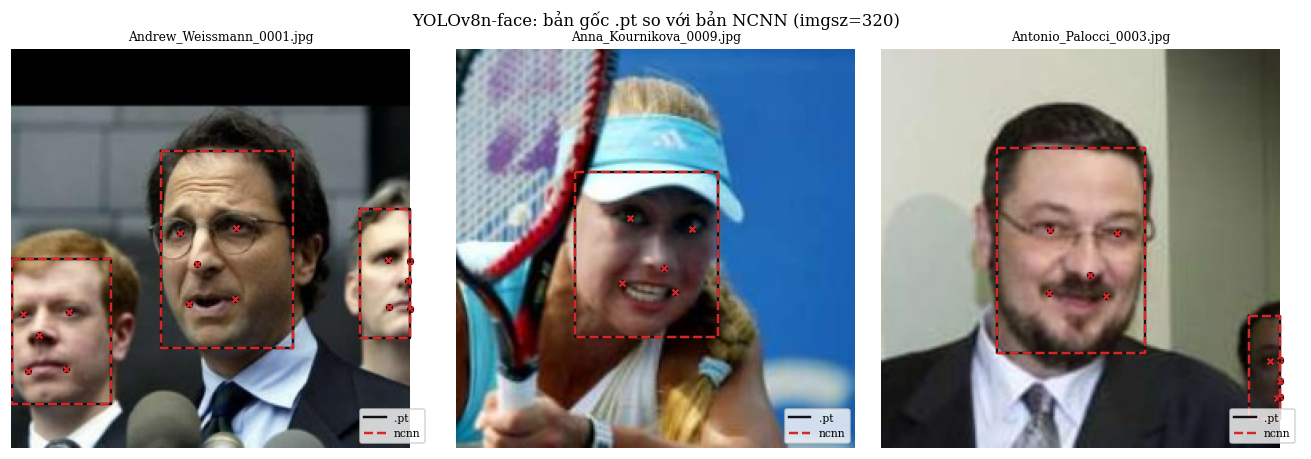

In [15]:
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 9,
})

IMGSZ_MINH_HOA = 320
m_ncnn = nap(thu_muc_ncnn[IMGSZ_MINH_HOA])
chon = anh[:3]

fig, axes = plt.subplots(1, len(chon), figsize=(4 * len(chon), 4.2))
for ax, a in zip(np.atleast_1d(axes), chon):
    anh_bgr = cv2.imread(str(a))
    ax.imshow(cv2.cvtColor(anh_bgr, cv2.COLOR_BGR2RGB))

    for nhan, mo_hinh, kieu, mau in [('.pt', mo_hinh_pt, '-', '#111111'),
                                     ('ncnn', m_ncnn, '--', '#d62728')]:
        khung, moc, co_moc = suy_luan(mo_hinh, a, IMGSZ_MINH_HOA)
        for i, k in enumerate(khung):
            x1, y1, x2, y2 = k
            ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1],
                    kieu, color=mau, linewidth=1.6,
                    label=nhan if i == 0 else None)
            if co_moc and moc is not None and len(moc) > i:
                ax.scatter(moc[i][:, 0], moc[i][:, 1], s=14, color=mau,
                           marker='o' if nhan == '.pt' else 'x')

    ax.set_title(a.name, fontsize=8)
    ax.axis('off')
    ax.legend(loc='lower right', fontsize=7)

plt.suptitle(f'YOLOv8n-face: bản gốc .pt so với bản NCNN (imgsz={IMGSZ_MINH_HOA})')
plt.tight_layout()
plt.show()

## 5. Kết luận

| Câu hỏi | Trả lời | Nguồn |
|---|---|---|
| Cấu trúc thư mục NCNN | Thư mục `yolov8n-face-<imgsz>_ncnn_model/` gồm bốn tệp: `model.ncnn.param` (~19 KB), `model.ncnn.bin` (~12,4 MB), `metadata.yaml` (449 B), `model_ncnn.py` (699 B) | mục 2.1 |
| `metadata.yaml` | Có. Ghi `task: pose`, `batch: 1`, `imgsz`, `names: {0: face}`, `kpt_shape`, và **`half: false`** | mục 2.2 |
| NCNN có trả điểm mốc | **Có** — 6/6 lượt kiểm ở cả hai độ phân giải | mục 3.1 |
| Độ khớp so với `.pt` | Khớp số mặt 12/12 · IoU lệch cỡ 10⁻⁷ · sai số điểm mốc cỡ 10⁻⁵ px | mục 3.2 |

### Ý nghĩa

`half: false` là chi tiết quyết định: bản NCNN **không** lượng tử hoá xuống fp16, nên sai số chỉ ở
mức làm tròn fp32. Phép chuyển đổi PyTorch → PNNX → NCNN vì thế **không làm mất mát gì đáng kể** về
mặt số học, dù đi qua nhiều chặng hơn đường ONNX.

Ba đường nạp thật sự tách biệt — nhật ký nạp mô hình ở mục 3.2 in rõ `for ONNX Runtime inference`
với bản ONNX và `for NCNN inference` với bản NCNN. Đây là bằng chứng cần thiết: một kết quả khớp
gần như hoàn hảo cũng là thứ sẽ xảy ra nếu hai phía vô tình nạp cùng một mô hình, nên phải phân biệt
hai khả năng đó bằng chứng cứ chứ không bằng con số.

### Điều notebook này KHÔNG nói

**Không có kết luận nào về tốc độ.** NCNN nhanh hơn hay chậm hơn ONNX trên Raspberry Pi 5 là câu
hỏi của bước 2.6, đo bằng `scripts/benchmark_detect.py` trên phần cứng thật. Kết quả ở đây chỉ nói
rằng bản NCNN **đúng**, tức là xứng đáng được đưa vào ma trận đo — chưa nói nó có thắng hay không.

### Việc tiếp theo

1. Review độc lập mã việc `P2-04`, ghi biên bản `docs/review/P2-04-export-ncnn.review.md`
2. Cập nhật bảng B của `models/README.md` bằng kích thước và `sha256` ở mục 2.1
3. Mã việc `P2-05` — backend NCNN trong `src/detector/`, thứ thật sự mở khoá ma trận đo 2.6:
   hiện `scripts/benchmark_detect.py` vẫn gán cứng `backend = "onnx"` vì khối phát hiện mới chỉ
   chạy được `onnxruntime`